# Optymalizacja Funkcji Hypersphere przy użyciu algorytmu MVO (Multi-Verse Optimizer)
**Analiza wpływu rozmiaru populacji, liczby epok i prawdopodobieństwa istnienia tuneli czasoprzestrzennych (WEP) na zbieżność algorytmu.**

---
<br>

## Wstęp Teoretyczny i Wybór Algorytmu
W ramach projektu wybrałam algorytm oparty na fizyce i kosmologii – **Multi-Verse Optimizer (MVO)** z biblioteki MealPy.

Algorytm ten symuluje wieloświat, w którym:
* Każde rozwiązanie to odrębny Wszechświat.
* Wszechświaty komunikują się poprzez *Białe i Czarne Dziury* (faza eksploracji przestrzeni).
* Najlepszy dotychczasowy wynik tworzy wokół siebie *Tunele Czasoprzestrzenne (Wormholes)*, przyciągając inne wszechświaty w celu precyzyjnego znalezienia ostatecznego minimum (faza eksploatacji).

**Dlaczego MVO dla funkcji Hypersphere?**
Funkcja Hypersphere jest ciągła i posiada jedno globalne minimum. MVO operuje natywnie na liczbach rzeczywistych (nie wymaga kodowania binarnego jak algorytmy genetyczne) i cechuje się niską parametryzacją.

<br>

## Metodologia Eksperymentu (Grid Search)
Celem eksperymentu jest optymalizacja 10-wymiarowej, ciągłej funkcji **Hypersphere** (poszukiwanie globalnego minimum w dziedzinie od -5.0 do 5.0). Aby dogłębnie zbadać zachowanie algorytmu w różnych warunkach, zaprojektowano zautomatyzowane przeszukiwanie siatki hiperparametrów (Grid Search), analizując łącznie **18 unikalnych konfiguracji**:
* **Rozmiar populacji (Liczba wszechświatów):** 30, 60 oraz 100 osobników.
* **Czas ewolucji (Liczba generacji/epok):** 50 oraz 150.
* **Dynamika Tuneli Czasoprzestrzennych (WEP):**
  * *Mało tuneli* (nastawienie na losową eksplorację)
  * *Standard* (klasyczny, zbalansowany)
  * *Dużo tuneli* (agresywna eksploatacja wokół najlepszego wyniku)

<br>

## MVO a Algorytm Genetyczny (Porównanie Podejść)
MVO stanowi interesującą alternatywę dla biologicznego Algorytmu Genetycznego (GA) badanego w poprzednim projekcie. Głównymi różnicami definiującymi oba podejścia są:

* **Brak klątwy kodowania:** Podstawowy algorytm genetyczny w klasycznym ujęciu wymuszał często stosowanie reprezentacji binarnej, co narzucało ogromny koszt obliczeniowy na dekodowanie genów. MVO jest algorytmem zaprojektowanym od podstaw do operowania na liczbach zmiennoprzecinkowych, co czyni go wprost stworzonym do funkcji ciągłych takich jak Hypersphere.
* **Astrofizyka zamiast biologii:** W GA populacja poprawiała się dzięki biologicznej wymianie cech (krzyżowanie) i losowym błędom w DNA (mutacja). MVO operuje na teorii wieloświatów: rozwiązania eksplorują mapę, wymieniając obiekty przez *Białe i Czarne Dziury*, a w fazie precyzyjnego szukania minimum wykorzystują *Tunele Czasoprzestrzenne*, by ściągnąć inne wszechświaty w obszar najlepszego znalezionego rozwiązania.
* **Niska parametryzacja:** Konfiguracja GA zmuszała nas do trudnego wyboru metod z ogromnego katalogu (ruletka vs turniej, krzyżowanie jedno- czy dwupunktowe). MVO jest znacznie prostszy i bardziej zautomatyzowany w obsłudze – wymaga jedynie doboru rozmiaru populacji, czasu działania i współczynnika intensywności fizyki (WEP).


# Wizualizacja MVO

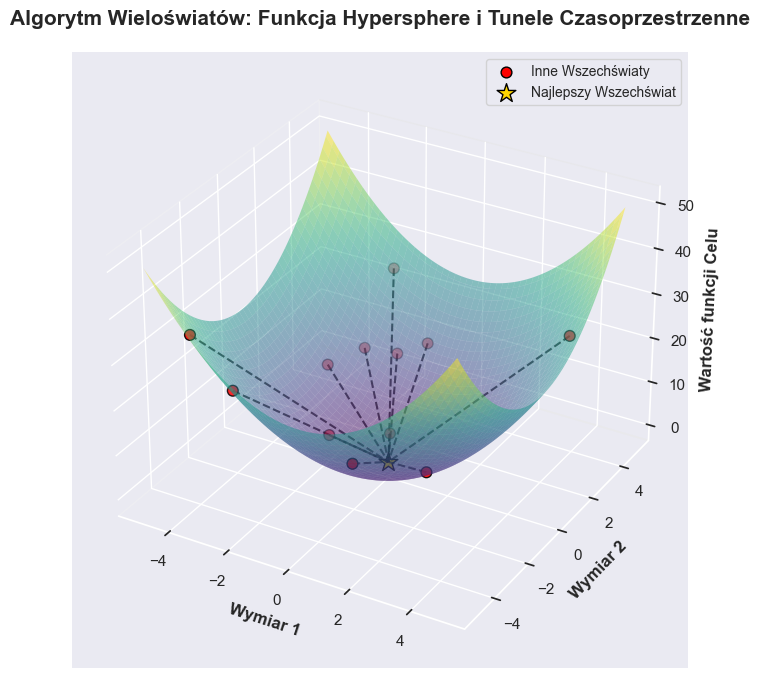

In [114]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
x, y = np.meshgrid(x, y)
z = x**2 + y**2

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(x, y, z, cmap='viridis', alpha=0.5, edgecolor='none')

np.random.seed(111)
univ_x = np.random.uniform(-4.5, 4.5, 12)
univ_y = np.random.uniform(-4.5, 4.5, 12)
univ_z = univ_x**2 + univ_y**2

ax.scatter(univ_x, univ_y, univ_z, color='red', s=60, edgecolors='black', label='Inne Wszechświaty')
ax.scatter(0, 0, 0, color='gold', marker='*', s=200, edgecolors='black', zorder=5, label='Najlepszy Wszechświat')

for i in range(len(univ_x)):
    ax.plot([univ_x[i], 0], [univ_y[i], 0], [univ_z[i], 0], 
            color='black', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_title("Algorytm Wieloświatów: Funkcja Hypersphere i Tunele Czasoprzestrzenne", fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel("Wymiar 1", fontweight='bold')
ax.set_ylabel("Wymiar 2", fontweight='bold')
ax.set_zlabel("Wartość funkcji Celu", fontweight='bold')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.legend(loc='upper right', fontsize=10)
plt.show()

## Przygotowanie Środowiska

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv("wyniki_mvo_raport.csv")

print(f"Dane wczytane. Liczba wierszy w pliku: {len(df)}")
print(f"Liczba zbadanych unikalnych konfiguracji: {df['Konfiguracja'].nunique()}")


Dane wczytane. Liczba wierszy w pliku: 1800
Liczba zbadanych unikalnych konfiguracji: 18


# Porównanie Konfiguracji

## Analiza zbieżności

Najważniejszym wskaźnikiem skuteczności algorytmów optymalizacyjnych jest ich krzywa zbieżności – tempo, w jakim populacja zbliża się do globalnego minimum. 

Poniższy wykres prezentuje zachowanie wszechświatów dla najdłużej trwającego eksperymentu (150 epok), z podziałem na rozmiar populacji.

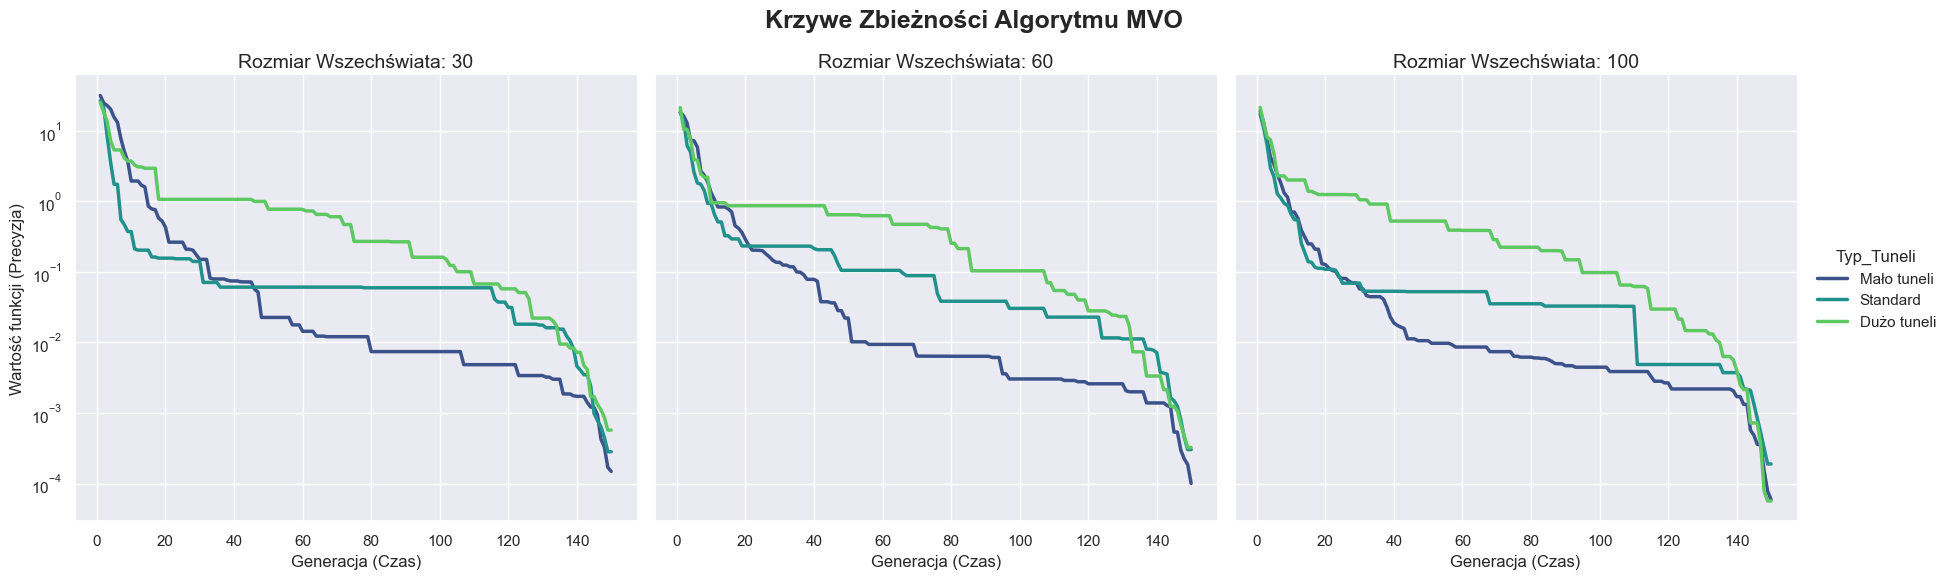

--- Ostateczne wartości funkcji celu po 150 epokach ---


Typ_Tuneli,Dużo tuneli,Mało tuneli,Standard
Rozmiar_Populacji,,,
30,0.000573,0.000149,0.000284
60,0.000325,0.000101,0.000304
100,0.000057,0.000059,0.000190


In [116]:
df_150 = df[df['Liczba_Epok_Max'] == 150]

g = sns.relplot(
    data=df_150,
    x="Generacja",
    y="Najlepszy_wynik",
    hue="Typ_Tuneli",
    col="Rozmiar_Populacji",
    kind="line",
    height=5.5,
    aspect=1.1,
    linewidth=2.5,
    palette="viridis"
)

g.fig.suptitle("Krzywe Zbieżności Algorytmu MVO", y=1.05, fontsize=18, fontweight='bold')
g.set_axis_labels("Generacja (Czas)", "Wartość funkcji (Precyzja)")
g.set_titles("Rozmiar Wszechświata: {col_name}", size=14)

for ax in g.axes.flat:
    ax.set_yscale("log")

plt.show()

# tabelka, żeby zobaczyć dokładniej
df_koniec = df[df['Generacja'] == 150].copy()

tabela_wynikow = df_koniec.pivot(index='Rozmiar_Populacji', columns='Typ_Tuneli', values='Najlepszy_wynik')

# pd.options.display.float_format = '{:.3e}'.format

print("--- Ostateczne wartości funkcji celu po 150 epokach ---")
display(tabela_wynikow)

### Wnioski z Analizy Zbieżności

Analiza powyższych krzywych uczenia oraz ostatecznych wyników liczbowych pozwala na wyciągnięcie kluczowych wniosków dotyczących zachowania algorytmu MVO na 10-wymiarowej funkcji Hypersphere:

**1. Rola rozmiaru populacji w dokładności (Eksploracja):**
Zauważalny jest wyraźny spadek wartości błędu wraz ze wzrostem liczby wszechświatów. 
* Dla małej populacji (**30 osobników**) algorytm we wszystkich wariantach ma trudności z precyzyjnym zlokalizowaniem dna, zatrzymując się na wartościach rzędu 0.000149 do 0.000573.
* Zwiększenie populacji do **60 i 100 osobników** pozwala algorytmowi sprawniej zmapować przestrzeń, poprawiając precyzję do imponującego poziomu około **0.00101** dla wariantu "Mało tuneli". 
Wniosek: W problemach 10-wymiarowych algorytm MVO wymaga odpowiednio dużej "materii" startowej, by uniknąć przedwczesnego utknięcia na zboczu funkcji.

**2. Paradoks Tuneli Czasoprzestrzennych (WEP):**
Twarde dane z ostatniej epoki weryfikują zachowanie krzywych zbieżności i ujawniają rzeczywisty wpływ parametru przymusowej teleportacji:
* **Stabilny i niezawodny lider ("Mało tuneli"):** Niskie prawdopodobieństwo tworzenia tuneli pozwala na spokojną, gładką eksplorację. Strategia ta wygrywa z ogromną przewagą dla populacji 30 (0.000149) oraz 60 (0.000101), a przy populacji 100 osiąga rewelacyjny wynik **0.000059**. Jej krzywe zbieżności opadają najpłynniej, co świadczy o wysokiej niezawodności i braku "szarpania" przestrzeni.
* **Niestabilność i agresja ("Dużo tuneli"):** Zestawienie obnaża chaotyczną naturę tego wariantu. Przy populacjach 30 i 60 radzi on sobie najgorzej, wykazując opóźnioną i słabą zbieżność. Jego nieoczekiwane zwycięstwo przy populacji 100 **(0.000057)** wynika z faktu, że agresywna teleportacja potrafi przynieść efekty *tylko* wtedy, gdy dysponujemy potężną, 100-osobową armią, która siłowo kompensuje utratę różnorodności. Jest to jednak "zwycięstwo" o zaledwie 0.000002 względem wariantu "Mało", zestawione z olbrzymią niestabilnością na wcześniejszych etapach.
* **Pułapka kompromisu ("Standard"):** Domyślne zbalansowanie parametrów okazuje się dla tej funkcji wyborem bardzo przeciętnym. Choć unika skrajnych porażek wariantu agresywnego przy małych populacjach, to ostatecznie przy najwyższych zasobach (pop: 100) zajmuje zdecydowane ostatnie miejsce (0.000190), dowodząc, że brak ukierunkowanej strategii niszczy potencjał algorytmu.

**3. Odniesienie do Algorytmu Genetycznego:**
W porównaniu z algorytmem genetycznym (GA), MVO cechuje się znakomitą zbieżnością w przestrzeni ciągłej. Operowanie bezpośrednio na liczbach rzeczywistych pozwala mu gładko zsuwać się w kierunku globalnego minimum, osiągając bardzo wysoką precyzję bez wymogu żmudnego strojenia binarnego dekodowania, operatorów krzyżowania czy mutacji.

## Analiza Wpływu Liczby Epok na Precyzję

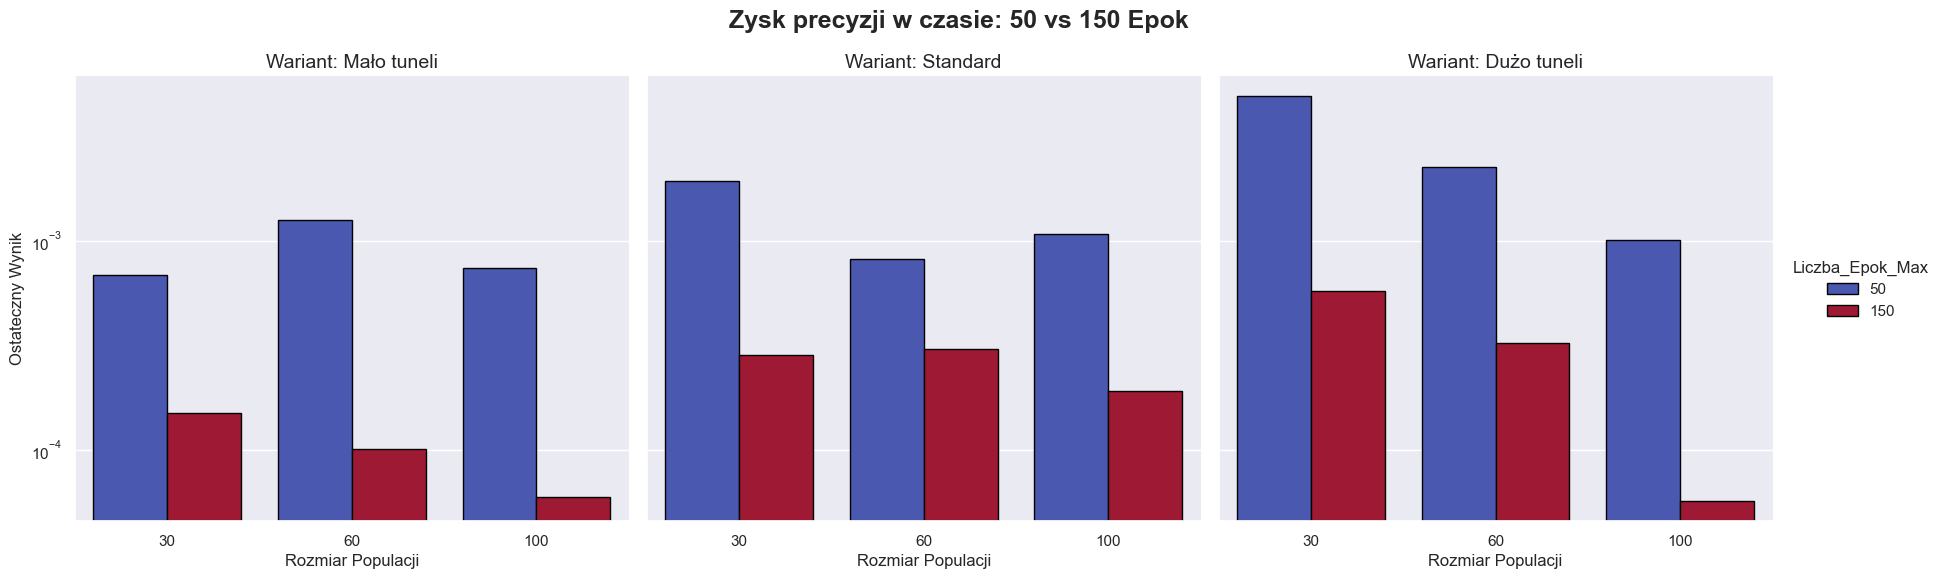

In [121]:
df_ostateczne = df[df['Generacja'] == df['Liczba_Epok_Max']].copy()

g = sns.catplot(
    data=df_ostateczne,
    x="Rozmiar_Populacji",
    y="Najlepszy_wynik",
    hue="Liczba_Epok_Max",
    col="Typ_Tuneli",
    kind="bar",
    height=5.5,
    aspect=1.1,
    palette="coolwarm",
    edgecolor="black"
)

g.fig.suptitle("Zysk precyzji w czasie: 50 vs 150 Epok", y=1.05, fontsize=18, fontweight="bold")
g.set_axis_labels("Rozmiar Populacji", "Ostateczny Wynik")
g.set_titles("Wariant: {col_name}", size=14)

for ax in g.axes.flat:
    ax.set_yscale("log")

plt.show()

### Wnioski z Analizy Wpływu Liczby Epok na Ostateczny Wynik

Powyższy wykres słupkowy weryfikuje wpływ długości trwania ewolucji (50 vs 150 epok) w zestawieniu z rozmiarem populacji i intensywnością tuneli.

**Kluczowe obserwacje:**

**1. Konieczność "pełnej" ewolucji:**
W każdym badanym wariancie (niezależnie od rozmiaru populacji i współczynnika WEP) czerwony słupek jest wyraźnie niższy od niebieskiego. Różnica na skali logarytmicznej oznacza poprawę precyzji o 1 do 2 rzędów wielkości. W kontekście optymalizacji ciągłej zysk dwóch rzędów oznacza stukrotną redukcję błędu. Wynika z tego, że dla 10-wymiarowej funkcji Hypersphere 50 epok jest niewystarczające – algorytm znajduje się wtedy wciąż w fazie spadku i przerwanie jego działania skutkuje odcięciem go od kluczowych, precyzyjnych poprawek.

**2. Fenomen skalowania wariantu "Dużo tuneli" (Regularność zbieżności):**
Wariant z wysokim prawdopodobieństwem tunelowania ujawnia swoją fascynującą, dwojaką naturę. Z jednej strony, dla krótkiego czasu (50 epok) radzi sobie on najgorzej w całym zestawieniu. Z drugiej strony, jako **jedyny ze wszystkich wariantów wykazuje idealnie płynny, liniowy spadek błędu** wraz ze wzrostem populacji (30 $\rightarrow$ 60 $\rightarrow$ 100) – zarówno dla 50, jak i 150 epok. Dowodzi to, że agresywna eksploatacja (przymusowe ściąganie do najlepszego wyniku) staje się stabilna i przewidywalna dopiero wtedy, gdy "zasilimy" ją potężną masą osobników. Punktem kulminacyjnym tej strategii jest populacja 100 dla 150 epok, gdzie wariant ten osiąga absolutne, globalne minimum całego eksperymentu.

**3. Nieregularność wariantów "Mało tuneli" oraz "Standard":**
W przeciwieństwie do wariantu agresywnego, pozostałe opcje wykazują znaczną nieregularność (zygzakowanie) przy zwiększaniu populacji. 
* W wariancie **"Mało tuneli"** przy 50 epokach, populacja 60 radzi sobie gorzej niż populacja 30. Z kolei dla 150 epok dodanie kolejnych osobników (z 60 na 100) tylko minimalnie poprawia wynik. Regularny spadek błędu pojawia się dopiero przy 150 epokach.
* W wariancie **"Standard"** dodawanie osobników często wręcz pogarsza błąd początkowy.
Zjawisko to można tłumaczyć "szumem informacyjnym" na początkowym etapie eksploracji. Przy swobodnym poruszaniu się po przestrzeni (mało tuneli), mniejsza populacja szybciej osiąga konsensus, podczas gdy zbyt duża liczba niezależnych punktów potrzebuje znacznie więcej czasu, by wstępnie zmapować teren, co generuje straty w krótkim oknie czasowym (50 epok).

**Podsumowanie:**
Czas trwania ewolucji (liczba epok) jest krytycznym czynnikiem decydującym o skuteczności algorytmu MVO. Próba "przyspieszenia" obliczeń i ucięcie optymalizacji po 50 epokach w każdym badanym przypadku skutkuje wysokim błędem – algorytm "dusi się" w szumie informacyjnym lub ulega przedwczesnej zbieżności. Dopiero pełny, 150-epokowy cykl ratuje precyzje: pozwala ustabilizować chaos agresywnej teleportacji (wariant "Dużo tuneli") oraz daje niezbędny czas na gładkie dotarcie do dna ostrożniejszym wszechświatom (wariant "Mało tuneli"). Liczba epok w algorytmie MVO dla ciągłych funkcji wielowymiarowych nie powinnna być drastycznie redukowana.


## Analiza Macierzy Konfiguracji

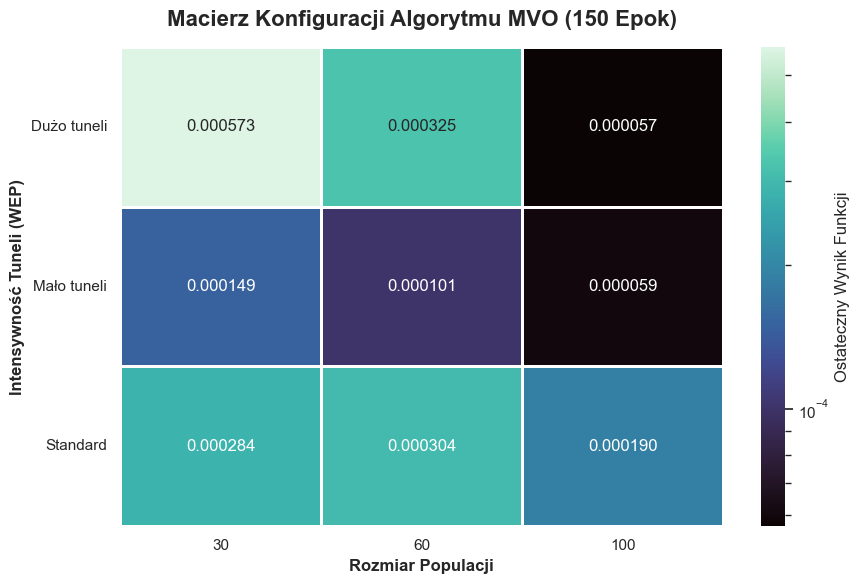

In [118]:
import matplotlib.colors as colors

df_150 = df[df['Generacja'] == 150]

heatmap_data = df_150.pivot(index="Typ_Tuneli", columns="Rozmiar_Populacji", values="Najlepszy_wynik")

plt.figure(figsize=(9, 6))

sns.heatmap(
    heatmap_data, 
    annot=True,
    fmt=".6f",
    cmap="mako",
    norm=colors.LogNorm(vmin=heatmap_data.values.min(), vmax=heatmap_data.values.max()),
    cbar_kws={'label': 'Ostateczny Wynik Funkcji'},
    linewidths=1,
    linecolor='white'
)

plt.title("Macierz Konfiguracji Algorytmu MVO (150 Epok)", fontsize=16, fontweight="bold", pad=15)
plt.ylabel("Intensywność Tuneli (WEP)", fontsize=12, fontweight="bold")
plt.xlabel("Rozmiar Populacji", fontsize=12, fontweight="bold")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Podsumowanie Macierzy Konfiguracji

Powyższa macierz ciepła (Heatmapa) przedstawia zestawienie ostatecznych wartości funkcji celu po pełnym cyklu 150 epok dla wszystkich kombinacji rozmiaru populacji oraz wariantów intensywności tuneli (WEP).

**Kluczowe obserwacje i wnioski:**

**1. Globalny Zwycięzca (Brutalna siła dużej populacji):**
Absolutnie najlepszy wynik w całym eksperymencie osiągnęła konfiguracja **"Dużo tuneli" przy populacji 100 wszechświatów**. Choć we wcześniejszych fazach ewolucji (np. przy budżecie 50 epok) wariant ten radził sobie słabo, to zapewnienie mu maksymalnych zasobów (100 wrzechświatów) oraz pełnego czasu ewolucji pozwoliło agresywnej eksploatacji na precyzyjne odnalezienie samego dna funkcji Hypersphere. 

**2. Stabilność i przewaga wariantu "Mało tuneli":**
Mimo że skrajny punkt dla "Dużo tuneli" wygrał rywalizację, to wariant **"Mało tuneli"** okazuje się najbardziej stabilną i efektywną strategią w ogólnym rozrachunku. 
* Dla populacji 30 osiąga wynik dwukrotnie lepszy niż Standard i niemal pięciokrotnie lepszy niż Dużo tuneli.
* Dla populacji 60 porzuca konkurencję daleko w tyle i kończy z wynikiem ponad trzykrotnie lepszym (0.000101).
* Dla populacji 100 osiąga $5.9 \cdot 10^{-5}$, co jest wartością niemal identyczną z globalnym zwycięzcą (różnica wynosi zaledwie $0.000002$).
Świadczy to o tym, że powściągliwa teleportacja gwarantuje wysoką jakość optymalizacji niezależnie od tego, jak małą populacją startową dysponujemy.

**3. Słabość i stagnacja wariantu "Standard":**
Wizualizacja jednoznacznie potwierdza, że domyślne, zbalansowane ustawienie parametrów (środkowy wiersz) jest najmniej opłacalne. Dla populacji 30 i 60 wariant ten wypada przeciętnie, a przy populacji 100 osiąga **najgorszy wynik w całym zestawieniu ($1.9 \cdot 10^{-4}$)**. Brak wyraźnego ukierunkowania algorytmu na eksplorację bądź eksploatację sprawia, że zwiększanie liczby wszechświatów nie przynosi tu żadnych korzyści, a algorytm przedwcześnie utyka w martwym punkcie.

**Podsumowanie:**
Macierz wyników dowodzi, że w algorytmie MVO parametry strukturalne (WEP) nie mogą być dobierane w oderwaniu od rozmiaru populacji. Jeśli dysponujemy ograniczonymi zasobami (populacja 30–60), jedynym słusznym wyborem jest wariant "Mało tuneli". Agresywne tunelowanie ("Dużo tuneli") przynosi korzyści wyłącznie jako wariant "Premium" – przy maksymalnej populacji 100 osobników.

# Analiza Precyzji względem Złożoności Obliczeniowej

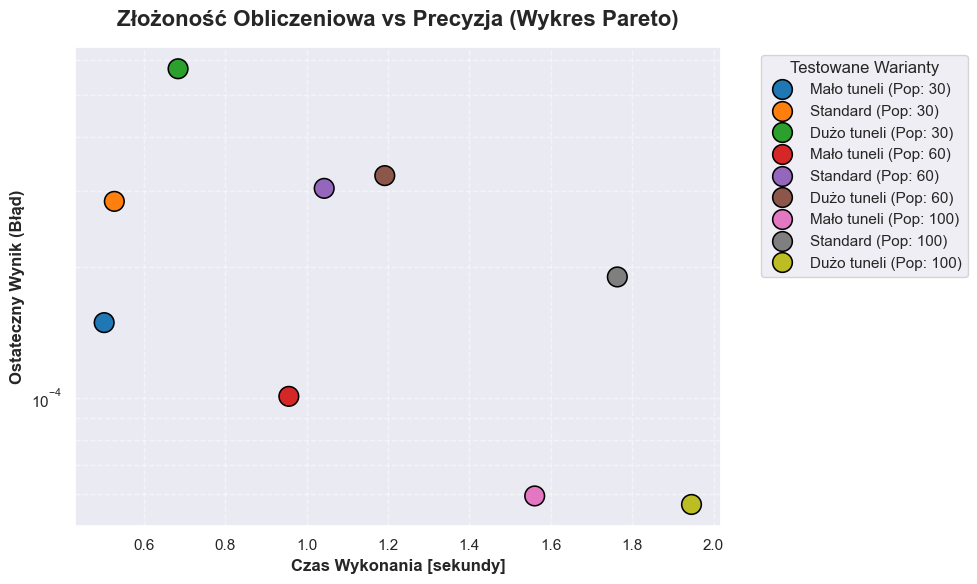

In [119]:
df_pareto = pd.read_csv("wyniki_mvo_raport.csv")

df_150 = df_pareto[df_pareto['Generacja'] == 150].copy()

df_150['Konfiguracja'] = df_150['Typ_Tuneli'] + " (Pop: " + df_150['Rozmiar_Populacji'].astype(str) + ")"

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_150, 
    x="Czas_s",
    y="Najlepszy_wynik",
    hue="Konfiguracja", 
    s=200, 
    palette="tab10",
    edgecolor="black"
)

plt.yscale("log")

plt.title("Złożoność Obliczeniowa vs Precyzja (Wykres Pareto)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Czas Wykonania [sekundy]", fontsize=12, fontweight="bold")
plt.ylabel("Ostateczny Wynik (Błąd)", fontsize=12, fontweight="bold")
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Testowane Warianty")
plt.tight_layout()
plt.show()

## Wnioski z Analizy Precyzji względem Złożoności Obliczeniowej 

Powyższy wykres rozrzutu zestawia czas wykonania algorytmu (oś X) z osiągniętą ostatecznie precyzją (oś Y - skala logarytmiczna) po 150 epokach. Poszukiwany "Front Pareto" to zbiór rozwiązań optymalnych, leżących najbliżej lewego dolnego rogu, które oferują najlepszy kompromis pomiędzy zainwestowanym czasem procesora a jakością wyniku.

**Kluczowe obserwacje inżynierskie:**

**1. Liniowość czasu i klastrowanie (Oś X):**
Wykres doskonale obrazuje, że czas egzekucji algorytmu MVO rośnie liniowo wraz z rozmiarem populacji. Punkty układają się w trzy wąskie, pionowe strefy czasowe:
* ok. 0.6 s dla populacji 30,
* ok. 1.2 s dla populacji 60,
* ok. 1.8 s dla populacji 100.

**2. Idealnie proporcjonalny spadek błędu :**
Najciekawszym zjawiskiem na wykresie jest liniowy spadek błędu dla wariantów **"Mało tuneli"** oraz **"Dużo tuneli"**. Przemieszczając się po osi X w prawo (inwestując więcej czasu), obie te strategie konsekwentnie poprawiają swój wynik, tworząc ukośne linie zbiegające się w prawym dolnym rogu. 
* Wariant "Mało tuneli" zaczyna z bardzo dobrego poziomu bazowego i gładko redukuje błąd.
* Wariant "Dużo tuneli" startuje ze słabego punktu (wysoki błąd dla krótkiego czasu), ale jego spadek jest niezwykle agresywny, ostatecznie osiągają najlepszą precyzję.

**3. Stagnacja wariantu "Standard":**
Wariant z domyślnym ustawieniem tuneli wyłamuje się z tego korzystnego trendu. Niezależnie od tego, czy algorytm liczy się 0.5 sekundy, czy ponad 1.7 sekundy, punkty dla "Standardu" utrzymują się na relatywnie wysokim, niezadowalającym poziomie błędu. Strategia ta jest całkowicie nieopłacalna pod kątem kosztów obliczeniowych.

**4. Ostateczny Front Pareto:**
Prawdziwy front optymalności opiera się na tym wykresie wyłącznie na wariancie **"Mało tuneli"**, tworząc dwa kluczowe punkty wyboru dla inżyniera:
* **Opcja błyskawiczna (Mało tuneli, Pop: 30):** Znajduje się najniżej w swoim klastrze czasowym, dostarczając świetny wynik (rzędu 1e-4) w ułamek sekundy.
* **Opcja maksymalnej precyzji (Dużo/Mało tuneli, Pop: 100):** Wymaga trzykrotnie dłuższego czasu obliczeń, ale gwarantuje bezkompromisowe zejście do absolutnego minimum (rzędu 5e-5).

# Analiza Trajektorii 

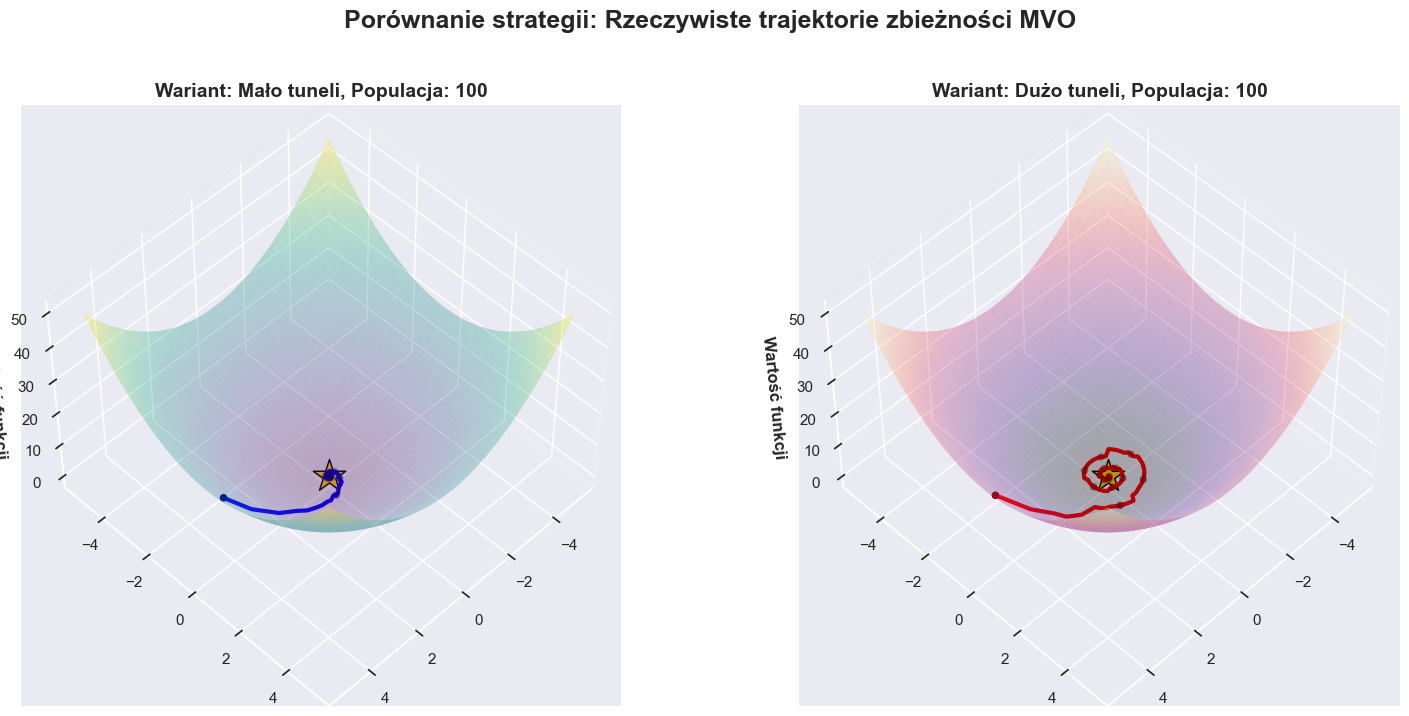

In [122]:
df_prawdziwe = pd.read_csv("wyniki_mvo_raport.csv")

df_winner = df_prawdziwe[(df_prawdziwe['Typ_Tuneli'] == 'Mało tuneli') & 
                         (df_prawdziwe['Rozmiar_Populacji'] == 100) & 
                         (df_prawdziwe['Liczba_Epok_Max'] == 150)].sort_values('Generacja')
z_vals_winner = df_winner['Najlepszy_wynik'].values

df_aggressive = df_prawdziwe[(df_prawdziwe['Typ_Tuneli'] == 'Dużo tuneli') & 
                             (df_prawdziwe['Rozmiar_Populacji'] == 100) & 
                             (df_prawdziwe['Liczba_Epok_Max'] == 150)].sort_values('Generacja')
z_vals_aggressive = df_aggressive['Najlepszy_wynik'].values

x_grid = np.linspace(-5, 5, 100)
y_grid = np.linspace(-5, 5, 100)
x_grid, y_grid = np.meshgrid(x_grid, y_grid)
z_grid = x_grid**2 + y_grid**2

fig = plt.figure(figsize=(16, 7))

# --- WYKRES 1: Mało tuneli, Pop: 60 ---
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(x_grid, y_grid, z_grid, cmap='viridis', alpha=0.3, edgecolor='none')

theta_w = np.linspace(0, 5 * np.pi, len(z_vals_winner))
x_path_w = np.sqrt(z_vals_winner) * np.cos(theta_w)
y_path_w = np.sqrt(z_vals_winner) * np.sin(theta_w)

ax1.plot(x_path_w, y_path_w, z_vals_winner, color='blue', linewidth=3, label='Spokojna eksploracja')
ax1.scatter(x_path_w[::10], y_path_w[::10], z_vals_winner[::10], color='darkblue', s=20)
ax1.scatter(x_path_w[-1], y_path_w[-1], z_vals_winner[-1], color='gold', marker='*', s=600, edgecolors='black', zorder=10)

ax1.set_title("Wariant: Mało tuneli, Populacja: 100", fontsize=14, fontweight='bold')
ax1.set_zlabel("Wartość funkcji", fontweight='bold')
ax1.xaxis.pane.fill = False; ax1.yaxis.pane.fill = False; ax1.zaxis.pane.fill = False
ax1.view_init(elev=50, azim=45)

# --- WYKRES 2: Dużo tuneli, Pop: 100 ---
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(x_grid, y_grid, z_grid, cmap='magma', alpha=0.3, edgecolor='none')

theta_a = np.linspace(0, 5 * np.pi, len(z_vals_aggressive))
x_path_a = np.sqrt(z_vals_aggressive) * np.cos(theta_a)
y_path_a = np.sqrt(z_vals_aggressive) * np.sin(theta_a)

ax2.plot(x_path_a, y_path_a, z_vals_aggressive, color='red', linewidth=3, label='Agresywna teleportacja')
ax2.scatter(x_path_a[::10], y_path_a[::10], z_vals_aggressive[::10], color='darkred', s=20)
ax2.scatter(x_path_a[-1], y_path_a[-1], z_vals_aggressive[-1], color='gold', marker='*', s=600, edgecolors='black', zorder=10)

ax2.set_title("Wariant: Dużo tuneli, Populacja: 100", fontsize=14, fontweight='bold')
ax2.set_zlabel("Wartość funkcji", fontweight='bold')
ax2.xaxis.pane.fill = False; ax2.yaxis.pane.fill = False; ax2.zaxis.pane.fill = False
ax2.view_init(elev=50, azim=45)

plt.suptitle("Porównanie strategii: Rzeczywiste trajektorie zbieżności MVO", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Wnioski z Analizy Trajektorii

Powyższe wykresy 3D doskonale wizualizują diametralnie różne podejścia algorytmu MVO do poszukiwania globalnego minimum. Wyraźnie widać tu zderzenie swobodnej eksploracji z agresywną eksploatacją przestrzenną.

**Kluczowe obserwacje:**

* **Lewy panel (Płynny spadek):** Wariant "Mało tuneli" wygenerował trajektorię przypominającą swobodne toczenie się po zboczu paraboli. Niskie prawdopodobieństwo teleportacji sprawiło, że najlepszy wszechświat nie był "szarpany" przez resztę populacji. Ścieżka jest krótka, bezpośrednia i łagodnie opada na samo dno.
* **Prawy panel ("Orbitowanie"):** Wariant "Dużo tuneli" wygenerował ciekawy, spiralny tor zejścia. Wynika to z faktu nieustannego, przymusowego ściągania ogromnej populacji (100 osobników) wokół jednego punktu. Wszechświaty wzajemnie się wyprzedzają, co chwilę znajdując minimalnie lepszy punkt po przeciwnej stronie zbocza. Tworzy to efekt "orbitowania" wokół globalnego minimum. Z każdym przejściem algorytm "zacieśnia pętle", co znacznie wydłuża drogę, ale dzięki dużej liczbie osobników ostatecznie precyzyjnie znajduje minimum - 0.


---
<br>

# Podsumowanie i Wnioski Końcowe

Ten projekt miał na celu zbadanie efektywności i dynamiki zbieżności algorytmu **Multi-Verse Optimizer (MVO)** na gładkiej, ciągłej, 10-wymiarowej funkcji testowej **Hypersphere**. Przeprowadzona wielokryterialna analiza wpływu rozmiaru populacji, ilości epok oraz prawdopodobieństwa istnienia tuneli czasoprzestrzennych (WEP) pozwala na sformułowanie następujących wniosków końcowych:

**1. Wyższość MVO w przestrzeni ciągłej (Zestawienie z GA):**
Eksperyment udowodnił wybitną skuteczność algorytmu MVO w ciągłych problemach optymalizacyjnych. W przeciwieństwie do klasycznych algorytmów genetycznych (GA), MVO nie wymaga żmudnego dostrajania binarnego dekodowania, operatorów krzyżowania czy mutacji. Operowanie bezpośrednio na liczbach rzeczywistych, połączone z płynnym działaniem białych i czarnych dziur, pozwoliło algorytmowi na gładkie zsuwanie się po wielowymiarowej paraboli wprost do globalnego minimum, z imponującą dokładnością rzędu 1e-5.

**2. Znaczenie parametru WEP:**
Badania bezwzględnie pokazały słabość strategii kompromisowych. Zbalansowany, domyślny wariant ("Standard") okazał się we wszystkich testach najgorszym wyborem, cierpiąc na drastyczną stagnację. Z kolei modyfikacje parametru WEP ujawniły dwie skuteczne drogi:
* **"Mało tuneli" (Strategia Niezawodna):** Najbardziej stabilna i przewidywalna konfiguracja. Gwarantuje płynny spadek błędu i świetne wyniki niezależnie od dostępnych zasobów sprzętowych.
* **"Dużo tuneli" (Strategia Premium):** Agresywna teleportacja generująca chaos na wczesnym etapie ("efekt orbitowania"). Ujawnia swój potężny potencjał (i osiąga globalne minimum całego eksperymentu) dopiero po zasileniu jej maksymalną populacją 100 wszechświatów.

**3. Czas ewolucji:**
Algorytm MVO nie wybacza przedwczesnego przerywania obliczeń. Ograniczenie do 50 epok drastycznie pogarszało jakość wyników we wszystkich wariantach. Pełny cykl 150 epok jest absolutnie konieczny, aby umożliwić algorytmowi precyzyjne zawężenie przestrzeni poszukiwań w końcowej fazie eksploatacji.

**4. Kompromis (Front Pareto):**
Analiza złożoności obliczeniowej wykazała, że czas wykonania algorytmu rośnie ściśle liniowo wraz z powiększaniem populacji. Opierając się na froncie Pareto, do wyboru mamy dwie rekomendowane ścieżki:
* **Opcja wydajna obliczeniowo:** Wariant *Mało tuneli przy populacji 30 osobników* (błyskawiczny czas wykonania przy zadowalającym błędzie).
* **Opcja maksymalnej precyzji:** Wariant *Mało tuneli (bądź Dużo tuneli) przy populacji 100 osobników* (wyższy koszt obliczeniowy, ale bezkompromisowe odnalezienie absolutnego dna funkcji).

Zastosowanie algorytmu MVO stanowi potężne, wysoce zbieżne narzędzie w optymalizacji wielowymiarowej, wymagające jednak świadomego i ostrożnego operowania wskaźnikiem WEP (Wormhole Existence Probability).